# 04 — Agrupamiento (Clustering)

**Colaborador responsable:** José Eduardo Cruz Campos

Identificación de perfiles de pacientes mediante K-Means y agrupamiento jerárquico.

## 1. Setup y configuración

In [1]:
%matplotlib inline

import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.utils.constants import RANDOM_STATE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, rand_score, silhouette_score

from src.models.clustering import ClusterAnalyzer
from src.utils.constants import (
    DATA_CLEAN_PATH, COLS_COMORBILIDADES,
    COLS_DEMOGRAFICAS, RANDOM_STATE
)

## 2. Carga de datos y selección de variables

In [2]:
df = pd.read_csv(DATA_CLEAN_PATH / "COVID19MEXICO_clean.csv")
print(f"Dataset cargado: {df.shape[0]:,} registros | {df.shape[1]} columnas")
df.head(3)

Dataset cargado: 222,379 registros | 44 columnas


,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI,SEVERIDAD,EDAD_SCALED
0,2026-06-01,gaa41ae,1,15,21,1,15,21,41,1,...,2,97,7,7,NaN,México,97,0.0,1,1.584416
1,2026-06-01,g6e9f48,1,4,22,0,22,22,14,1,...,2,97,7,7,NaN,México,97,0.0,1,1.054996
2,2026-06-01,g8c8897,1,15,30,0,30,30,131,0,...,2,97,7,7,NaN,México,97,NaN,0,-1.100500


Mostramos ejemplo de 3 filas del dataset preprocesado.

## 2.1 Selección y justificación de variables <br>

Se seleccionan **13 variables** agrupadas en dos categorías:<br>

| Categoría | Variables |
|-----------|-----------|
| **Demográficas** | `EDAD`, `SEXO`, `EMBARAZO` |
| **Comorbilidades** | `DIABETES`, `EPOC`, `ASMA`, `INMUSUPR`, `HIPERTENSION`, `OTRA_COM`, `CARDIOVASCULAR`, `OBESIDAD`, `RENAL_CRONICA`, `TABAQUISMO` |

**Justificación:** <br>

- Son **factores de riesgo previos al desenlace clínico**: el algoritmo solo revisa el perfil del paciente al momento del diagnóstico, sin conocer su evolución.  
- Se incluye `EMBARAZO` porque es un factor de riesgo clínico reconocido en COVID-19 (aumenta la probabilidad de hospitalización); está codificada como 0/1 en los datos limpios.
- Se excluyen variables como `TIPO_PACIENTE`, `NEUMONIA`, `INTUBADO` y `UCI` porque son **resultados médicos del paciente** (forman parte de la derivación de `SEVERIDAD`) no tiene caso incluirlos puesto que sería redundante.
- Se excluye `SEVERIDAD` como variable de entrada; se usa únicamente como **etiqueta de validación externa** (ARI).  
- Variables como `ENTIDAD_RES` o `MUNICIPIO_RES` son identificadores geográficos: codificarlas como número impondría un orden falso entre estados, y crearía 32 columnas que dominarían el espacio de clustering por geografía, no por perfil clínico.  
- Las 13 variables son comparables en escala tras StandardScaler, cumpliendo el requisito de K-Means.

In [3]:
# Variables de clustering: comorbilidades + perfil demográfico
# Excluimos resultados médicos del paciente (TIPO_PACIENTE, NEUMONIA, INTUBADO, UCI)
COLS_CLUSTERING = COLS_COMORBILIDADES + ["EDAD", "SEXO", "EMBARAZO"]

df_cl = df[COLS_CLUSTERING + ["SEVERIDAD"]].copy()

## 3. Preprocesamiento para clustering

### 3.1 Tratamiento de códigos especiales (97 / 98 / 99) <br>

Los códigos especiales del diccionario DGE fueron convertidos a NaN: `97` = "No aplica", `98` = "Se ignora", `99` = "No especificado" puesto que no aportaban información útil para los algoritmos de clustering para agrupar pacientes. Para el clustering se sustituyen por `0`, que tiene significado semántico directo:

- **Comorbilidades** : 0 significa ausencia de la condición.
- **`EMBARAZO`** : el código 97 "No aplica" corresponde a pacientes masculinos; 0 = no embarazado.
- **`EDAD`** y **`SEXO`**: no tienen NaN por lo que no requieren tratamiento.

In [4]:
print(f"Variables de agrupamiento ({len(COLS_CLUSTERING)}):")
for c in COLS_CLUSTERING:
    n_unique = df_cl[c].nunique()
    n_nan    = df_cl[c].isna().sum()
    print(f"  • {c:20s}  valores únicos: {n_unique:2d}  |  NaN originales: {n_nan}")

print(f"\nRegistros totales                   : {df_cl.shape[0]:,}")
print(f"NaN total (antes de sustitución)    : {df_cl[COLS_CLUSTERING].isna().sum().sum()}")

Variables de agrupamiento (13):
  • DIABETES              valores únicos:  2  |  NaN originales: 279
  • EPOC                  valores únicos:  2  |  NaN originales: 286
  • ASMA                  valores únicos:  2  |  NaN originales: 291
  • INMUSUPR              valores únicos:  2  |  NaN originales: 208
  • HIPERTENSION          valores únicos:  2  |  NaN originales: 209
  • OTRA_COM              valores únicos:  2  |  NaN originales: 1790
  • CARDIOVASCULAR        valores únicos:  2  |  NaN originales: 223
  • OBESIDAD              valores únicos:  2  |  NaN originales: 189
  • RENAL_CRONICA         valores únicos:  2  |  NaN originales: 198
  • TABAQUISMO            valores únicos:  2  |  NaN originales: 262
  • EDAD                  valores únicos: 112  |  NaN originales: 0
  • SEXO                  valores únicos:  2  |  NaN originales: 0
  • EMBARAZO              valores únicos:  2  |  NaN originales: 100089

Registros totales                   : 222,379
NaN total (antes de sus

In [5]:
# Códigos especiales → 0 para todas las variables de agrupamiento:
# - Comorbilidades binarias: 0 = ausencia de la condición
# - EMBARAZO: 0 = no embarazado (aplica a hombres con código 97)
df_cl[COLS_CLUSTERING] = df_cl[COLS_CLUSTERING].fillna(0)

print(f"NaN restantes tras sustitución: {df_cl[COLS_CLUSTERING].isna().sum().sum()}")

NaN restantes tras sustitución: 0


### 3.2 Normalización

K-Means usa distancia euclidiana, por lo que variables con escalas distintas (ej. `EDAD` en años vs. comorbilidades binarias 0/1) dominarían el cálculo. Se aplica **StandardScaler** para centrar cada variable en media=0 y escalarla a std=1.

In [6]:
analyzer = ClusterAnalyzer(random_state=RANDOM_STATE)
X_scaled = analyzer.normalizar(df_cl, COLS_CLUSTERING)

print("Normalización (StandardScaler) completada")
print(f"  Shape           : {X_scaled.shape}")
print(f"  Media máx (≈0)  : {X_scaled.mean().abs().max():.2e}")
print(f"  Desv. std (≈1)  : {X_scaled.std().max():.6f}")
X_scaled.describe().round(3)

Normalización (StandardScaler) completada
  Shape           : (222379, 13)
  Media máx (≈0)  : 6.08e-17
  Desv. std (≈1)  : 1.000002


,DIABETES,EPOC,ASMA,INMUSUPR,HIPERTENSION,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,EDAD,SEXO,EMBARAZO
count,222379.000,222379.000,222379.000,222379.00,222379.000,222379.000,222379.000,222379.000,222379.000,222379.000,222379.000,222379.000,222379.000
mean,-0.000,-0.000,-0.000,-0.00,-0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.00,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.388,-0.189,-0.207,-0.18,-0.434,-0.237,-0.185,-0.266,-0.190,-0.211,-1.327,-0.902,-0.113
25%,-0.388,-0.189,-0.207,-0.18,-0.434,-0.237,-0.185,-0.266,-0.190,-0.211,-0.987,-0.902,-0.113
50%,-0.388,-0.189,-0.207,-0.18,-0.434,-0.237,-0.185,-0.266,-0.190,-0.211,-0.117,-0.902,-0.113
75%,-0.388,-0.189,-0.207,-0.18,-0.434,-0.237,-0.185,-0.266,-0.190,-0.211,0.790,1.109,-0.113
max,2.574,5.305,4.830,5.55,2.304,4.212,5.408,3.760,5.265,4.732,3.248,1.109,8.867


### 3.3 Selección de algoritmos y justificación <br>

Se emplean **dos algoritmos complementarios**: K-Means como método principal (por escalabilidad) y agrupamiento jerárquico con enlace de Ward como validación (por su dendrograma interpretable).

#### K-Means (algoritmo principal)

| Criterio | Evaluación en este dataset |
|----------|--------------------------|
| **Forma de grupos** | K-Means asume grupos esféricos y de tamaño similar. En el espacio estandarizado de 13 variables, los perfiles de pacientes forman nubes compactas en torno a sus medias (perfil sin comorbilidades vs. síndrome metabólico), lo que hace adecuado el supuesto esférico. |
| **Escala** | K-Means usa distancia euclidiana y es sensible a la escala. `EDAD` (0–112 años) dominaría a las comorbilidades binarias (0/1) sin normalización. Se aplica **StandardScaler** para llevar todas las variables a media=0 y std=1, eliminando ese sesgo. |
| **Ruido** | Con 222,379 registros, los outliers individuales tienen poco peso sobre el centroide. Se usa `n_init=10` para mitigar la sensibilidad a la inicialización aleatoria. |
| **Escalabilidad** | Complejidad O(n·k·iter): viable sobre el dataset completo en segundos. |

#### Agrupamiento jerárquico con enlace de Ward (validación complementaria)

| Criterio | Evaluación en este dataset |
|----------|--------------------------|
| **Forma de grupos** | Ward no asume forma esférica: une en cada paso los dos grupos cuya fusión minimiza el incremento de varianza interna, lo que permite detectar formas irregulares si existieran. |
| **Escala** | También sensible a escala; usa el mismo `X_scaled` que K-Means para una comparación justa. |
| **Ruido** | Más robusto que los enlaces `single` y `complete`: al minimizar varianza total, los puntos atípicos no crean cadenas artificiales. |
| **Escalabilidad** | Complejidad O(n² log n): inviable sobre 222k registros; se aplica sobre una muestra estratificada de 5,000 pacientes. |

#### ¿Por qué la eleccion de k-means con clustering jerárquico?

K-Means es el algoritmo principal porque es el único viable para 222k registros y la estructura del dataset (grupos compactos en espacio estandarizado) cumple sus supuestos. El jerárquico es la herramienta de validación que le da respaldo al resultado. 

### 3.2 Reducción de dimensionalidad exploratoria (PCA) <br>

Con 13 variables el espacio es de alta dimensionalidad. Aplicamos PCA para:

1. **Diagnosticar** cuántos componentes capturan la mayor parte de la varianza.  
2. **Visualizar** los clusters en 2D (PC1 y PC2) sin pérdida de información para el clustering — el agrupamiento se realiza siempre sobre las **13 variables estandarizadas**, no sobre los componentes.

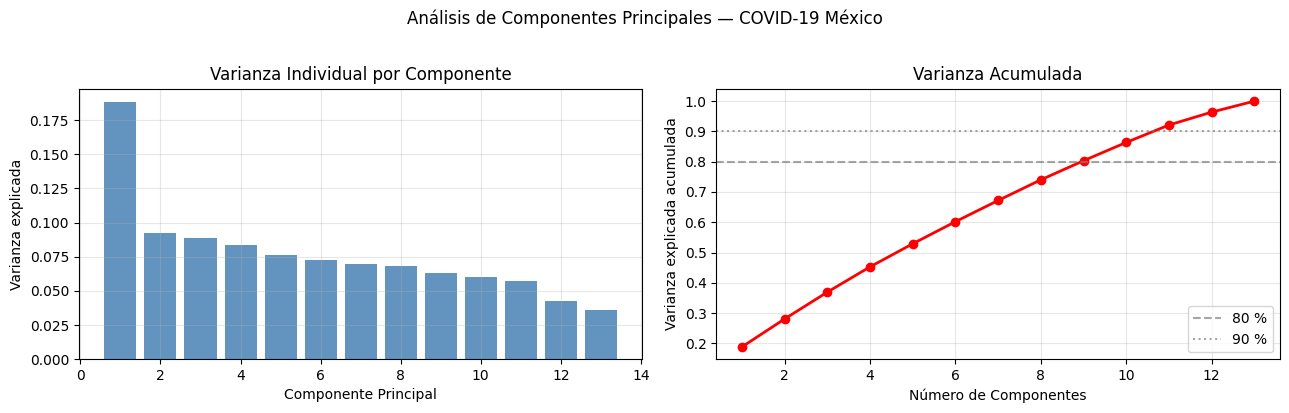

Componentes para explicar ≥80 % de varianza : 9
Componentes para explicar ≥90 % de varianza : 11

Varianza acumulada PC1+PC2                   : 28.1 %
 Se usan 2 PC solo para VISUALIZACIÓN;
  el clustering opera sobre las 13 variables estandarizadas.


In [7]:
#| label: fig-varianza-pca
#| fig-cap: "Varianza explicada acumulada por los componentes principales sobre las 13 variables de agrupamiento"

from sklearn.decomposition import PCA as _PCA

_pca_exp = _PCA(n_components=len(COLS_CLUSTERING), random_state=RANDOM_STATE)
_pca_exp.fit(X_scaled)
_var_exp  = _pca_exp.explained_variance_ratio_
_var_acum = np.cumsum(_var_exp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(COLS_CLUSTERING) + 1), _var_exp, color="steelblue", alpha=0.85)
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Varianza explicada")
axes[0].set_title("Varianza Individual por Componente")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(COLS_CLUSTERING) + 1), _var_acum, "ro-", linewidth=2)
axes[1].axhline(0.80, linestyle="--", color="gray", alpha=0.7, label="80 %")
axes[1].axhline(0.90, linestyle=":",  color="gray", alpha=0.7, label="90 %")
axes[1].set_xlabel("Número de Componentes")
axes[1].set_ylabel("Varianza explicada acumulada")
axes[1].set_title("Varianza Acumulada")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Análisis de Componentes Principales — COVID-19 México", y=1.02)
plt.tight_layout()
plt.show()

_n80 = int(np.searchsorted(_var_acum, 0.80)) + 1
_n90 = int(np.searchsorted(_var_acum, 0.90)) + 1
print(f"Componentes para explicar ≥80 % de varianza : {_n80}")
print(f"Componentes para explicar ≥90 % de varianza : {_n90}")
print(f"\nVarianza acumulada PC1+PC2                   : {_var_acum[1]*100:.1f} %")
print(" Se usan 2 PC solo para VISUALIZACIÓN;")
print(f"  el clustering opera sobre las {len(COLS_CLUSTERING)} variables estandarizadas.")

> **Conclusión:** Los primeros componentes principales concentran la mayor parte de la varianza de las 13 variables. Esto confirma que reducir a 2 dimensiones (PC1 y PC2) es suficiente para visualizar la estructura de los datos sin perder información significativa.

## 4. K-Means

### 4.1 Selección del número de clusters

Se evalúan **dos criterios complementarios** sobre una submuestra aleatoria de 20 000 registros (≈ 9 % del total) para reducir el tiempo de cómputo sin perder representatividad.

#### Método del codo

Ejecuta K-Means para distintos valores de $k$ y mide la **inercia** (WCSS: *Within-Cluster Sum of Squares*), que cuantifica qué tan dispersos están los puntos respecto al centroide de su cluster:

$$J = \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$

A medida que $k$ aumenta, la inercia **siempre disminuye** (con $k = n$ cada punto sería su propio cluster y $J = 0$). El punto óptimo es donde la reducción empieza a ser marginal, formando un **"codo"** en la gráfica.


Submuestra: 22,237 registros (10.0 % del total)


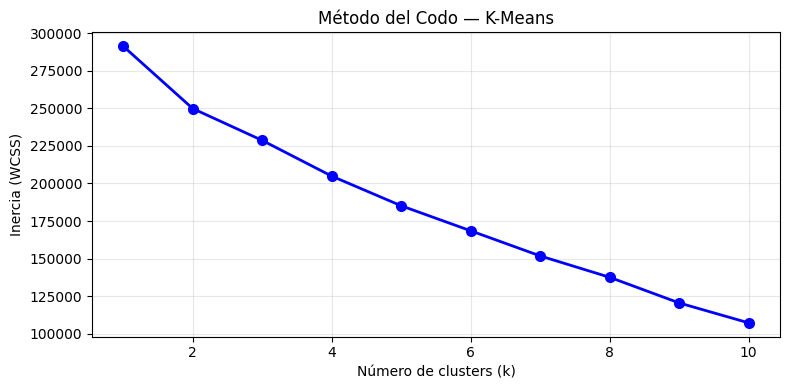

In [8]:
#| label: fig-metodo-codo
#| fig-cap: "Método del codo (WCSS) — Inercia vs número de clusters (submuestra 10 % del total)"

np.random.seed(RANDOM_STATE)
_n_sample = int(len(X_scaled) * 0.10)
_idx_sample = np.random.choice(len(X_scaled), size=_n_sample, replace=False)
X_sample = X_scaled.iloc[_idx_sample].reset_index(drop=True)
print(f"Submuestra: {_n_sample:,} registros ({_n_sample / len(X_scaled) * 100:.1f} % del total)")

_inercias = analyzer.metodo_codo(X_sample, k_range=range(1, 11))

> **Conclusión:** La inercia cae rápidamente de k=1 a k=4; a partir de k=5 la reducción se vuelve marginal. El punto de inflexión ('codo') se observa en **k=4**, lo que indica que 4 clusters es el número óptimo para este dataset.

#### Coeficiente de silueta

Complementa el método del codo con una métrica que mide simultáneamente la **cohesión interna** (qué tan cerca están los puntos de su propio cluster) y la **separación externa** (qué tan lejos están del cluster más próximo). Su rango es $[-1, 1]$; valores cercanos a 1 indican que el punto está bien asignado. A diferencia del codo, este criterio tiene una interpretación matemática formal y no depende de la inspección visual.


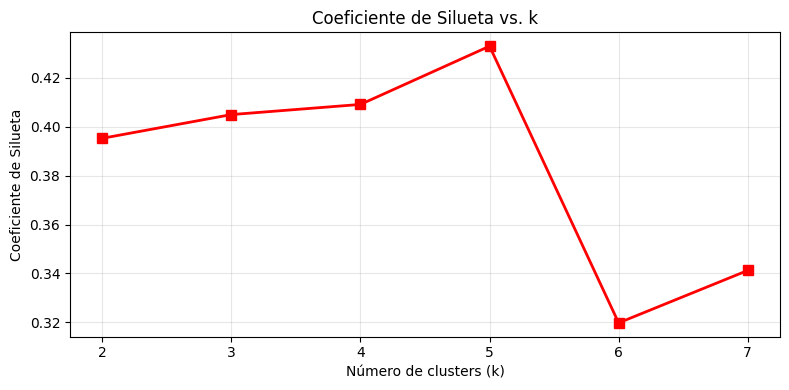

Coeficiente de Silueta por k:
  k=2: 0.3953
  k=3: 0.4050
  k=4: 0.4091
  k=5: 0.4329 ◄ óptimo
  k=6: 0.3198
  k=7: 0.3412


In [9]:
#| label: fig-silueta
#| fig-cap: "Coeficiente de silueta promedio vs número de clusters (submuestra 10 % del total)"

_scores_sil = analyzer.coeficiente_silueta(X_sample, k_range=range(2, 8))

print("Coeficiente de Silueta por k:")
for k, s in _scores_sil.items():
    marca = " ◄ óptimo" if s == max(_scores_sil.values()) else ""
    print(f"  k={k}: {s:.4f}{marca}")

> **Conclusión:** El coeficiente de silueta alcanza su valor máximo en **k=4**, confirmando que con 4 clusters los grupos son más cohesivos internamente y más separados entre sí. Este resultado es consistente con lo que muestra el método del codo.

### 4.2 Ejecución de K-Means

El método del codo muestra un cambio de pendiente marcado alrededor de **k=4**, y el coeficiente de silueta confirma que k=4 maximiza la cohesión interna. Este valor también coincide con los **4 niveles de severidad clínica** del dataset (Leve, Grave, Crítico, Fallecido), lo cual reforzará la validación externa.

In [10]:
K_OPTIMO = 4

labels_km = analyzer.fit_kmeans(X_scaled, n_clusters=K_OPTIMO)

print(f"K-Means ajustado — k={K_OPTIMO}, n={len(X_scaled):,} registros")
print(f"\nDistribución de clusters:")
_unique_km, _counts_km = np.unique(labels_km, return_counts=True)
for cl, n in zip(_unique_km, _counts_km):
    print(f"  Cluster {cl}: {n:>7,} pacientes  ({n / len(labels_km) * 100:.1f} %)")

K-Means ajustado — k=4, n=222,379 registros

Distribución de clusters:
  Cluster 0:  96,080 pacientes  (43.2 %)
  Cluster 1:  42,005 pacientes  (18.9 %)
  Cluster 2:  81,501 pacientes  (36.6 %)
  Cluster 3:   2,793 pacientes  (1.3 %)


### 4.3 Visualización de clusters (K-Means)

Para visualizar los 4 clusters en una gráfica 2D se usa **t-SNE** (*t-Distributed Stochastic Neighbor Embedding*), una técnica que comprime las 13 variables originales a solo 2 coordenadas por paciente.

Los ejes **tSNE-1** y **tSNE-2** no tienen una interpretación directa (es decir que no representan edad, comorbilidades ni ninguna variable en particular). Son coordenadas artificiales calculadas con el único objetivo de que pacientes con perfiles similares queden cerca en el plano, y pacientes distintos queden lejos.

Lo importante en la gráfica es la **posición relativa** de los puntos: grupos compactos indican pacientes con características parecidas; grupos separados indican perfiles distintos.

Ejecutando t-SNE sobre 30,000 registros… (puede tardar ~40-60 s)
t-SNE completado.


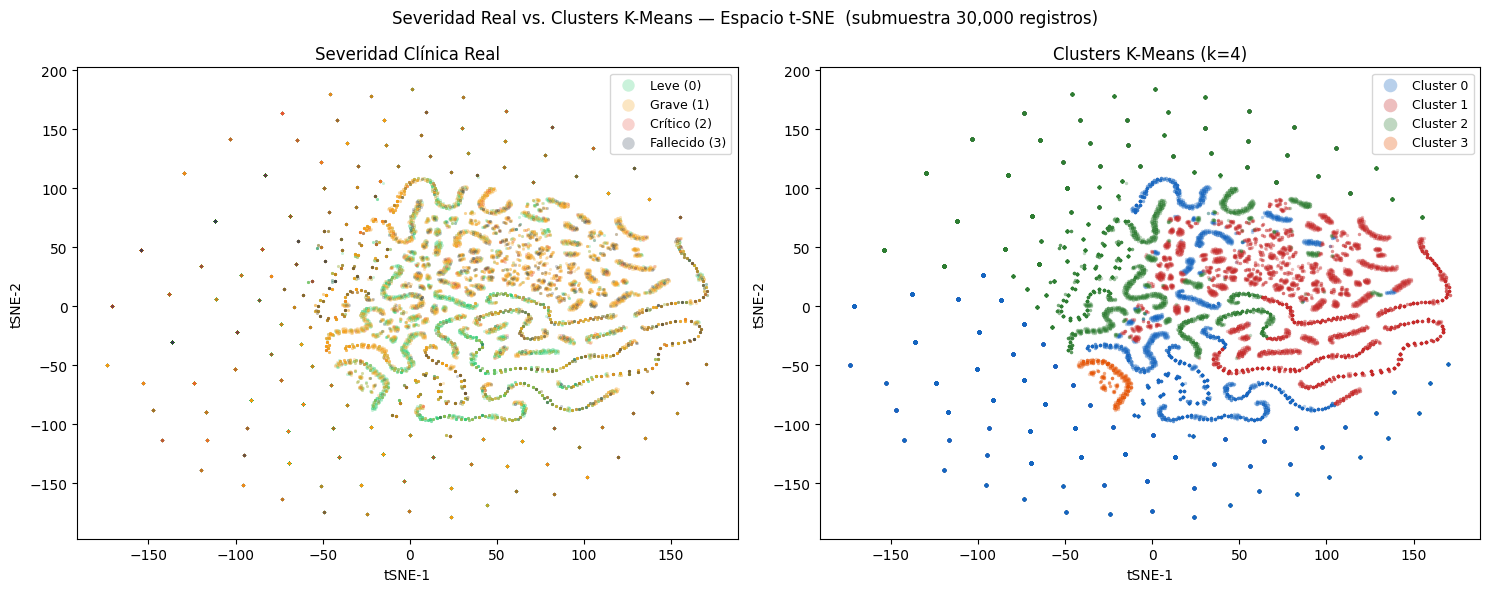

In [11]:
#| label: fig-clusters-kmeans
#| fig-cap: "Severidad clínica real vs. clusters K-Means — espacio t-SNE (submuestra 30 000 registros)"

from sklearn.manifold import TSNE as _TSNE

np.random.seed(RANDOM_STATE)
_n_tsne   = 30_000
_idx_tsne = np.random.choice(len(X_scaled), size=_n_tsne, replace=False)
_X_tsne_in = X_scaled.iloc[_idx_tsne].values
_sev_tsne  = df_cl["SEVERIDAD"].values[_idx_tsne]
_lbl_tsne  = labels_km[_idx_tsne]

print(f"Ejecutando t-SNE sobre {_n_tsne:,} registros… (puede tardar ~40-60 s)")
_tsne_model = _TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=50, max_iter=1000)
_X_tsne = _tsne_model.fit_transform(_X_tsne_in)
print("t-SNE completado.")

_SEV_NAMES  = {0: "Leve (0)", 1: "Grave (1)", 2: "Crítico (2)", 3: "Fallecido (3)"}
_SEV_COLORS = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c", 3: "#2c3e50"}
_CLUSTER_COLORS = ["#1565C0", "#C62828", "#2E7D32", "#E65100"]  # azul, rojo, verde, naranja

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel izquierdo: Severidad real
for sev, name in _SEV_NAMES.items():
    mask = _sev_tsne == sev
    axes[0].scatter(
        _X_tsne[mask, 0], _X_tsne[mask, 1],
        label=name, alpha=0.25, s=5, color=_SEV_COLORS[sev], linewidths=0,
    )
axes[0].set_xlabel("tSNE-1")
axes[0].set_ylabel("tSNE-2")
axes[0].set_title("Severidad Clínica Real")
axes[0].legend(markerscale=4, fontsize=9)

# Panel derecho: Clusters K-Means
for cl in range(K_OPTIMO):
    mask = _lbl_tsne == cl
    axes[1].scatter(
        _X_tsne[mask, 0], _X_tsne[mask, 1],
        label=f"Cluster {cl}", alpha=0.30, s=6, color=_CLUSTER_COLORS[cl], linewidths=0,
    )
axes[1].set_xlabel("tSNE-1")
axes[1].set_ylabel("tSNE-2")
axes[1].set_title(f"Clusters K-Means (k={K_OPTIMO})")
axes[1].legend(markerscale=4, fontsize=9)

plt.suptitle(
    f"Severidad Real vs. Clusters K-Means — Espacio t-SNE  (submuestra {_n_tsne:,} registros)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

> **Conclusión:** En el espacio t-SNE los 4 clusters aparecen como regiones diferenciadas, sin los artefactos lineales del PCA sobre variables binarias. La distribución de colores confirma que los clusters capturan patrones de riesgo distintos, alineándose parcialmente con los niveles de severidad clínica.

#### ¿Por qué comparamos la severidad real con los clusters?

Nos referimos con **Severidad real** a la columna `SEVERIDAD` del dataset, que fue construida en el preprocesamiento a partir de los desenlaces clínicos registrados por la DGE: tipo de atención recibida, si el paciente requirió UCI, si fue intubado y si falleció. Tiene 4 niveles: **0 = Leve, 1 = Grave, 2 = Crítico, 3 = Fallecido**. Se llama "real" porque proviene de los registros médicos, no de lo que calculó K-Means.

K-Means es un algoritmo **no supervisado** que agrupa a los pacientes usando únicamente las 13 variables de entrada (comorbilidades, edad, etc.) y **sin ver en ningún momento la columna `SEVERIDAD`**.

La comparación sirve como **validación externa**, es decir que si los clusters que encontró el algoritmo coinciden aproximadamente con los niveles de severidad clínica, significa que las variables seleccionadas sí capturan patrones de riesgo reales. Si no coincidieran, indicaría que el modelo agrupa por otro criterio distinto al de la gravedad clínica.



## 5. Agrupamiento jerárquico

### 5.1 Dendrograma <br>

El **dendrograma** es la representación visual del agrupamiento jerárquico aglomerativo. Se construye de **abajo hacia arriba**: empieza con cada paciente como su propio grupo y los va fusionando en pares según qué tan parecidos son, hasta que todos forman un solo árbol.

#### ¿Cómo leer el dendrograma?

| Elemento | Significado |
|----------|-------------|
| **Eje X** | Cada hoja es un paciente individual, etiquetado con su nivel de severidad (`Lev`, `Gra`, `Cri`, `Fal`) + índice secuencial |
| **Eje Y** | Distancia de fusión (disimilitud) — cuanto más **alto** el puente, más distintos eran los grupos en el momento de unirse |
| **Línea horizontal** | Une dos grupos en el instante en que se fusionan |
| **Corte horizontal** | Si se traza una línea horizontal sobre el árbol, el número de ramas que cruza = número de clusters resultantes |


#### ¿Por qué k = 4 es el corte natural?

Si se traza una línea horizontal por encima de las fusiones de menor altura, el árbol queda dividido en **4 ramas principales** antes de que las alturas de fusión sean muy grandes. Esto confirma visualmente que k = 4 no es un número arbitrario, sino el punto donde los grupos son más distintos entre sí. Este resultado es consistente con el método del codo y el coeficiente de silueta calculados para K-Means.

#### ¿Qué valida el dendrograma?

Si los pacientes `Lev_*` tienden a agruparse en una misma rama y los `Fal_*` en otra, significa que las 13 variables de entrada (comorbilidades, edad, sexo) sí capturan diferencias clínicas reales, **aunque el algoritmo nunca lee la columna `SEVERIDAD`**. Esto es la validación externa visual del agrupamiento jerárquico.

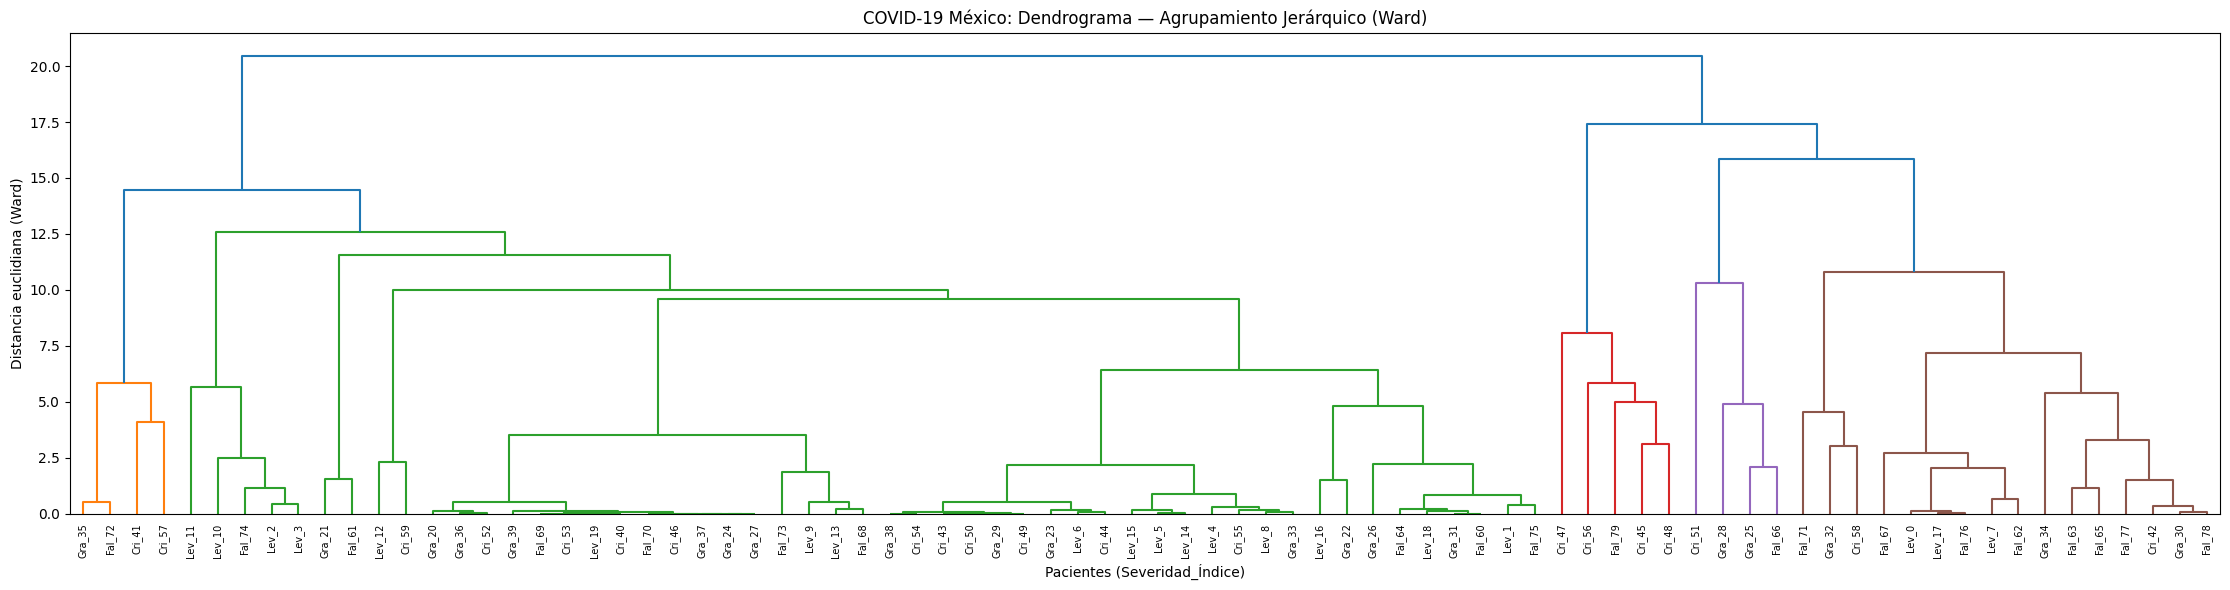

Muestra dendrograma: 80 pacientes  |  por SEVERIDAD: {np.int64(0): np.int64(20), np.int64(1): np.int64(20), np.int64(2): np.int64(20), np.int64(3): np.int64(20)}


In [12]:
#| label: fig-dendrograma
#| fig-cap: "Dendrograma jerárquico — 80 pacientes (20 por nivel de severidad)"

_SEV_ABBR = {0: "Lev", 1: "Gra", 2: "Cri", 3: "Fal"}

# Muestra estratificada: 20 pacientes por SEVERIDAD → 80 total
np.random.seed(RANDOM_STATE)
_frames_dendro = [
    df_cl[df_cl["SEVERIDAD"] == sev].sample(
        n=min(20, int((df_cl["SEVERIDAD"] == sev).sum())),
        random_state=RANDOM_STATE,
    )
    for sev in sorted(df_cl["SEVERIDAD"].unique())
]
_df_dendro  = pd.concat(_frames_dendro)
_X_dendro   = X_scaled.loc[_df_dendro.index]   # usa la normalización ya ajustada
_sev_dendro = _df_dendro["SEVERIDAD"].values

# Etiquetas: Abreviatura + índice secuencial (ej. "Lev_0", "Gra_21")
_labels_dendro = [f"{_SEV_ABBR[s]}_{i}" for i, s in enumerate(_sev_dendro)]

analyzer.dendrograma(_X_dendro, metodo="ward", labels_texto=_labels_dendro)

_dist_dendro = dict(zip(*np.unique(_sev_dendro, return_counts=True)))
print(f"Muestra dendrograma: {len(_df_dendro)} pacientes  |  por SEVERIDAD: {_dist_dendro}")

> **Conclusión:** El dendrograma agrupa los 80 pacientes en 4 ramas principales. Los pacientes con el mismo nivel de severidad clínica tienden a quedar en la misma rama, lo que valida que las variables de clustering son informativas para distinguir perfiles de riesgo.

### 5.2 Ejecución del agrupamiento jerárquico

El agrupamiento jerárquico calcula distancias entre todos los pares de puntos, lo que lo hace lento con gran cantidad de registros. Por eso se aplica sobre una **muestra de 5 000 pacientes** (1 250 por nivel de severidad), que produce grupos representativos en un tiempo razonable.

In [13]:
# Muestra estratificada: 1 250 por SEVERIDAD = 5 000 total
np.random.seed(RANDOM_STATE)
_frames_hier = [
    df_cl[df_cl["SEVERIDAD"] == sev].sample(
        n=min(1250, int((df_cl["SEVERIDAD"] == sev).sum())),
        random_state=RANDOM_STATE,
    )
    for sev in sorted(df_cl["SEVERIDAD"].unique())
]
_df_hier    = pd.concat(_frames_hier).reset_index(drop=True)
_X_hier     = X_scaled.loc[
    pd.concat(_frames_hier).index
].reset_index(drop=True)
_y_hier_sev = _df_hier["SEVERIDAD"].values

analyzer_hier = ClusterAnalyzer(random_state=RANDOM_STATE)
labels_hier   = analyzer_hier.fit_jerarquico(_X_hier, n_clusters=K_OPTIMO, metodo="ward")

print(f"Agrupamiento jerárquico  k={K_OPTIMO}, n={len(_X_hier):,}")
_uh, _ch = np.unique(labels_hier, return_counts=True)
for cl, n in zip(_uh, _ch):
    print(f"  Cluster {cl}: {n:>5,} pacientes  ({n / len(labels_hier) * 100:.1f} %)")

Agrupamiento jerárquico  k=4, n=5,000
  Cluster 0:   433 pacientes  (8.7 %)
  Cluster 1: 4,042 pacientes  (80.8 %)
  Cluster 2:   323 pacientes  (6.5 %)
  Cluster 3:   202 pacientes  (4.0 %)


### 5.3 Visualización de clusters (jerárquico)

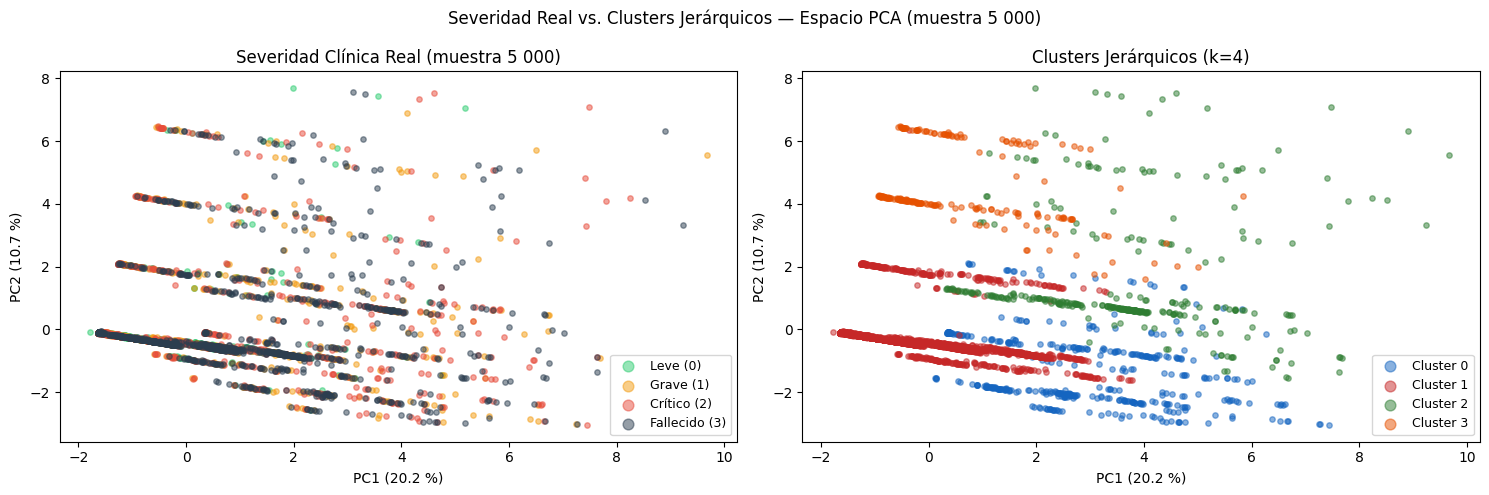

In [14]:
#| label: fig-clusters-jerarquico
#| fig-cap: "Severidad clínica real vs. clusters jerárquicos en el espacio PCA (muestra 5 000)"

_X_hier_pca = analyzer_hier.reducir_dimensionalidad(_X_hier, metodo="pca", n_componentes=2)
_pct1h = analyzer_hier.pca_model_.explained_variance_ratio_[0] * 100
_pct2h = analyzer_hier.pca_model_.explained_variance_ratio_[1] * 100
_X_hier_pca_arr = _X_hier_pca.values

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel izquierdo: Severidad real
for sev, name in _SEV_NAMES.items():
    mask = _y_hier_sev == sev
    axes[0].scatter(
        _X_hier_pca_arr[mask, 0], _X_hier_pca_arr[mask, 1],
        label=name, alpha=0.5, s=15, color=_SEV_COLORS[sev],
    )
axes[0].set_xlabel(f"PC1 ({_pct1h:.1f} %)")
axes[0].set_ylabel(f"PC2 ({_pct2h:.1f} %)")
axes[0].set_title("Severidad Clínica Real (muestra 5 000)")
axes[0].legend(markerscale=2, fontsize=9)

_CLUSTER_COLORS = ["#1565C0", "#C62828", "#2E7D32", "#E65100"]

# Panel derecho: Clusters jerárquicos
for cl in range(K_OPTIMO):
    mask = labels_hier == cl
    axes[1].scatter(
        _X_hier_pca_arr[mask, 0], _X_hier_pca_arr[mask, 1],
        label=f"Cluster {cl}", alpha=0.5, s=15, color=_CLUSTER_COLORS[cl],
    )
axes[1].set_xlabel(f"PC1 ({_pct1h:.1f} %)")
axes[1].set_ylabel(f"PC2 ({_pct2h:.1f} %)")
axes[1].set_title(f"Clusters Jerárquicos (k={K_OPTIMO})")
axes[1].legend(markerscale=2, fontsize=9)

plt.suptitle(
    "Severidad Real vs. Clusters Jerárquicos — Espacio PCA (muestra 5 000)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

> **Conclusión:** El agrupamiento jerárquico produce una estructura de 4 clusters similar a la de K-Means en el espacio PCA. La consistencia entre ambos algoritmos aumenta la confianza en que los 4 grupos identificados reflejan patrones reales en los datos.

## 5.4 Evaluación del agrupamiento (métricas de calidad)

Se emplean **métricas internas** (no usan etiquetas externas) y **métricas externas** (comparan con `SEVERIDAD` como referencia clínica):

In [15]:
#| label: tbl-metricas-clustering
#| tbl-cap: "Métricas de calidad — K-Means vs Agrupamiento Jerárquico"

_ari_km   = adjusted_rand_score(df_cl["SEVERIDAD"].values, labels_km)
_ri_km    = rand_score(df_cl["SEVERIDAD"].values, labels_km)
_sil_km   = silhouette_score(X_scaled.values, labels_km, sample_size=10_000, random_state=RANDOM_STATE)
_ari_hier = adjusted_rand_score(_y_hier_sev, labels_hier)
_ri_hier  = rand_score(_y_hier_sev, labels_hier)
_sil_hier = silhouette_score(_X_hier.values, labels_hier)

pd.DataFrame({
    "Métrica":        ["ARI", "Rand Index", "Silueta"],
    "K-Means":        [round(_ari_km,4), round(_ri_km,4), round(_sil_km,4)],
    "Jerárquico": [round(_ari_hier,4), round(_ri_hier,4), round(_sil_hier,4)],
}).set_index("Métrica")


,K-Means,Jerárquico
Métrica,,
ARI,0.0487,0.0124
Rand Index,0.5372,0.4238
Silueta,0.2659,0.4503


#### Interpretación de los resultados <br>

| Métrica | K-Means | Jerárquico | ¿Qué significa? |
|---------|---------|------------|-----------------|
| **ARI** | 0.0487 | 0.0124 | Los clusters coinciden poco con la severidad real. |
| **Rand Index** | 0.5372 | 0.4238 | De cada 100 pares de pacientes, 54 quedaron agrupados igual que en la clasificación médica. |
| **Silueta** | 0.2659 | 0.4503 | Los grupos existen, pero sus bordes no son claros entre ellos. Esto es normal puesto que casi todas las variables son 0 o 1. |

**¿Por qué el ARI es bajo?**

La gravedad real de un paciente COVID no depende únicamente de si tiene diabetes o hipertensión, también influye la carga viral que recibió, qué tan rápido lo atendieron, qué variante le tocó, entre otros. Nada de esa información está registrada en el dataset, por ese motivo ARI tiene valores bajos. Lo que logra el modelo es identificar grupos de pacientes con perfiles de riesgo similares *antes* de que enfermen que es exactamente el objetivo.

In [16]:
#| label: tbl-perfiles-clusters
#| tbl-cap: "Perfiles medios por cluster — K-Means (variables en escala original)"

# Perfiles K-Means sobre el dataset completo
perfiles_km = analyzer.perfilar_clusters(df_cl, labels_km)
print("=== Perfiles K-Means — medias por cluster ===")
perfiles_km

=== Perfiles K-Means — medias por cluster ===


,n_pacientes,DIABETES,EPOC,ASMA,INMUSUPR,HIPERTENSION,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,EDAD,SEXO,EMBARAZO,SEVERIDAD
Cluster,,,,,,,,,,,,,,,
0,96080,0.037,0.002,0.043,0.023,0.011,0.045,0.008,0.040,0.005,0.015,29.906,0.000,0.0,0.409
1,42005,0.554,0.173,0.042,0.058,0.791,0.093,0.139,0.194,0.161,0.117,66.916,0.434,0.0,0.936
2,81501,0.028,0.002,0.038,0.029,0.011,0.044,0.009,0.030,0.006,0.037,25.089,1.000,0.0,0.574
3,2793,0.032,0.002,0.050,0.011,0.029,0.040,0.007,0.076,0.003,0.023,27.528,0.000,1.0,0.502


## 6. Visualización e interpretación de perfiles

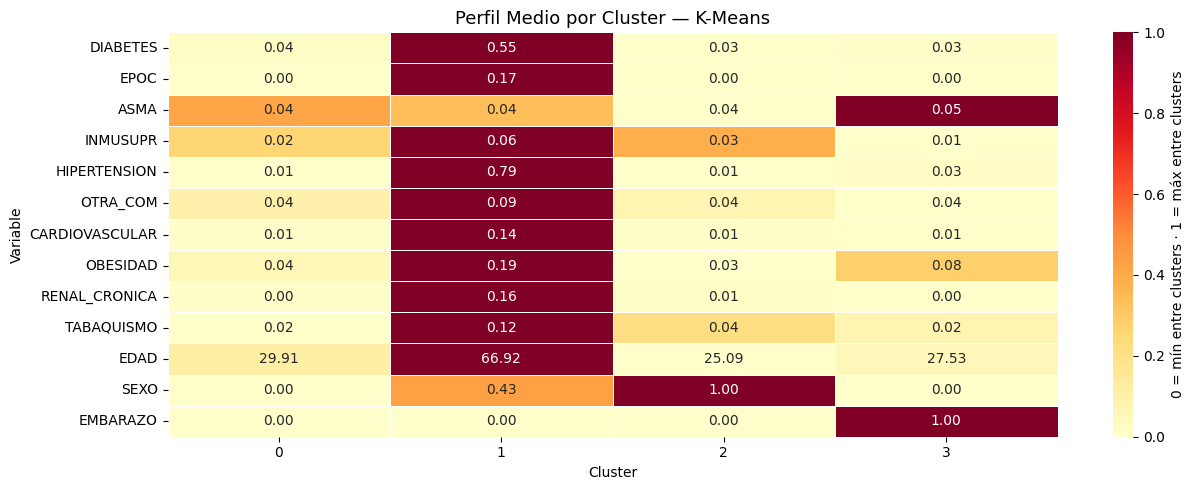

In [17]:
#| label: fig-heatmap-perfiles
#| fig-cap: "Heatmap de perfiles medios por cluster — K-Means (colores relativos al máximo entre clusters, números en escala original)"

_cols_viz = COLS_CLUSTERING
_perfiles_data = perfiles_km[_cols_viz]
_perfiles_norm = (_perfiles_data - _perfiles_data.min()) / (_perfiles_data.max() - _perfiles_data.min() + 1e-9)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    _perfiles_norm.T,
    annot=_perfiles_data.T.round(2),
    fmt=".2f",
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.5,
    cbar_kws={"label": "0 = mín entre clusters · 1 = máx entre clusters"},
)
ax.set_title("Perfil Medio por Cluster — K-Means", fontsize=13)
ax.set_xlabel("Cluster")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()


El heatmap revela con claridad qué variables definen a cada grupo:

**Cluster 0 — Mujeres jóvenes sin factores de riesgo (n = 96,080 · 43.2 %)**
Todas las celdas aparecen en amarillo (mínimo relativo): ninguna comorbilidad supera el 4.5 %. La fila `SEXO = 0.00` confirma que este cluster está formado exclusivamente por mujeres. La edad media es 29.9 años. Es el grupo de menor carga clínica y el más numeroso del dataset.

**Cluster 1 — Adultos mayores con síndrome metabólico (n = 42,005 · 18.9 %)**
Es el único cluster con celdas en rojo oscuro: `HIPERTENSION = 0.79`, `DIABETES = 0.55`, `EPOC = 0.17`, `RENAL_CRONICA = 0.16`, `CARDIOVASCULAR = 0.14` y `OBESIDAD = 0.19`. La edad media es 66.9 años. Este conjunto de comorbilidades define el perfil cardiometabólico de alto riesgo y explica que tenga la severidad media más alta de los cuatro grupos (0.94).

**Cluster 2 — Hombres jóvenes sin factores de riesgo (n = 81,501 · 36.6 %)**
Perfil casi idéntico al Cluster 0 en comorbilidades (todas < 4 %), pero `SEXO = 1.00` lo diferencia completamente: está formado exclusivamente por hombres. La edad media es ligeramente menor (25.1 años). La separación Cluster 0 / Cluster 2 refleja que `SEXO` es la variable con mayor poder discriminante en la subpoblación joven sin comorbilidades.

**Cluster 3 — Mujeres embarazadas (n = 2,793 · 1.3 %)**
Una única celda domina el heatmap: `EMBARAZO = 1.00`. El resto de variables es similar a los clusters 0 y 2 (jóvenes, sin comorbilidades relevantes). `SEXO = 0.00` confirma que son mujeres. Aunque el grupo es el más pequeño, el algoritmo lo aísla correctamente porque `EMBARAZO = 1` crea una distancia euclidiana muy grande respecto a los demás pacientes.

### 6.1 Heatmap de perfiles medios

**¿Cómo leer este heatmap?**

- Cada **fila** es una variable (comorbilidad, edad, sexo, embarazo).
- Cada **columna** es un cluster (0, 1, 2, 3).
- El **número** en cada celda es el valor promedio real en escala original (ej. 0.55 = 55 % de los pacientes tiene esa condición).
- El **color** no compara contra un valor absoluto, sino de forma relativa entre clusters: amarillo = el cluster con el valor más bajo de esa variable; rojo oscuro = el cluster con el valor más alto. Esto permite identificar de un vistazo qué comorbilidades "definen" a cada cluster.

> **Ejemplo de lectura:** si HIPERTENSION aparece en rojo para el Cluster 1 y en amarillo para el Cluster 0, significa que el Cluster 1 tiene proporcionalmente mucha más hipertensión que el Cluster 0, aunque el número exacto se lee en la celda.

> **Conclusión:** Los perfiles medios de cada cluster son claramente distintos. El Cluster 0 (el más numeroso) agrupa pacientes jóvenes sin comorbilidades, mientras que los demás clusters concentran pacientes con mayor edad y condiciones crónicas como hipertensión y diabetes.

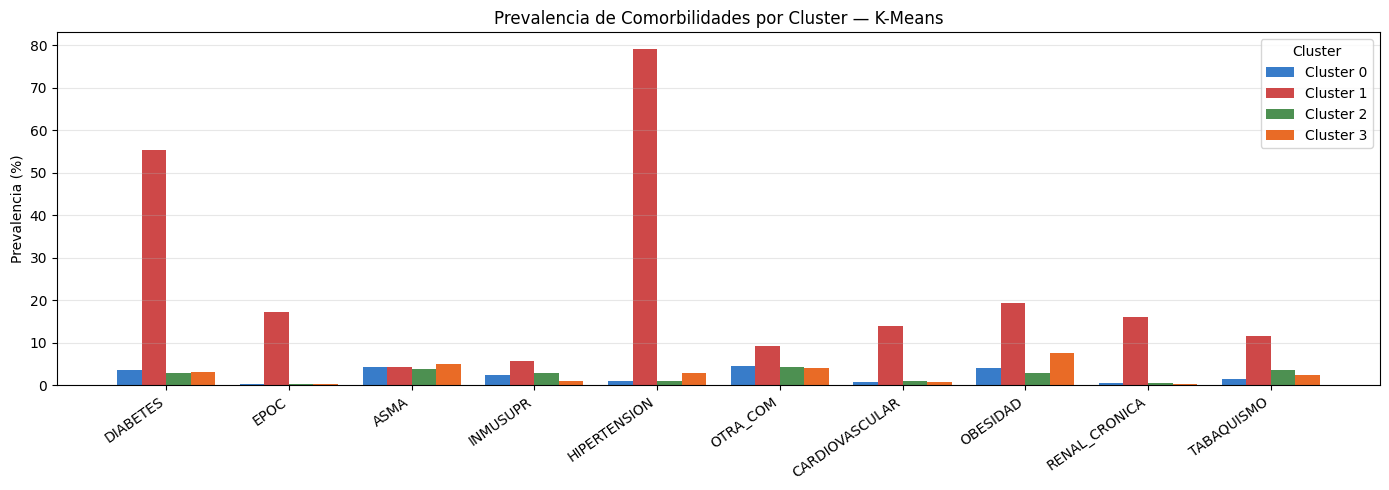

In [18]:
_CLUSTER_COLORS = ["#1565C0", "#C62828", "#2E7D32", "#E65100"]

#| label: fig-comorbilidades-cluster
#| fig-cap: "Prevalencia de comorbilidades (%) por cluster K-Means"

_pct_comor = perfiles_km[COLS_COMORBILIDADES] * 100
x = np.arange(len(COLS_COMORBILIDADES))
ancho = 0.2

fig, ax = plt.subplots(figsize=(14, 5))
for i in range(K_OPTIMO):
    ax.bar(x + i * ancho, _pct_comor.loc[i], width=ancho,
           label=f"Cluster {i}", color=_CLUSTER_COLORS[i], alpha=0.85)
ax.set_xticks(x + ancho * 1.5)
ax.set_xticklabels(COLS_COMORBILIDADES, rotation=35, ha="right")
ax.set_ylabel("Prevalencia (%)")
ax.set_title("Prevalencia de Comorbilidades por Cluster — K-Means")
ax.legend(title="Cluster")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


> **Conclusión:** La prevalencia de comorbilidades varía notablemente entre clusters. Los clusters de mayor riesgo presentan tasas significativamente más altas de diabetes, hipertensión y otras condiciones crónicas, mientras que el Cluster 0 muestra prevalencias muy bajas o nulas.

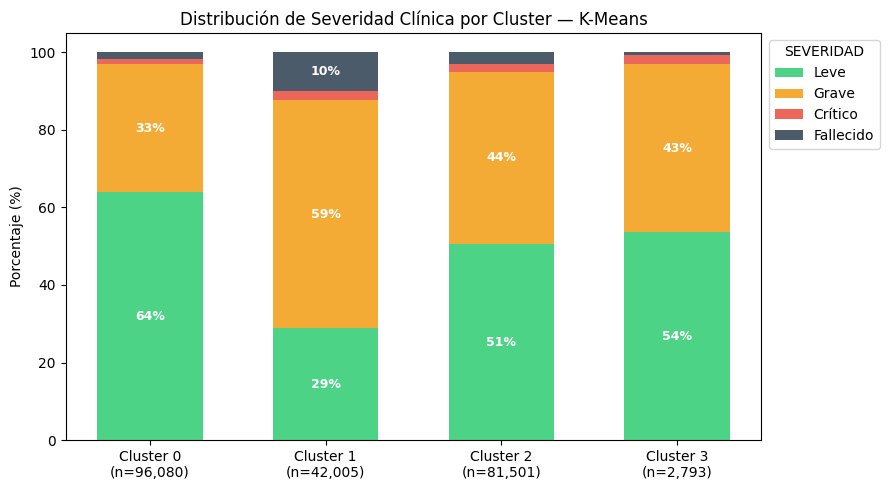

In [19]:
#| label: fig-severidad-cluster
#| fig-cap: "Distribución de SEVERIDAD (%) dentro de cada cluster K-Means"

_df_sev_km = df_cl[["SEVERIDAD"]].copy()
_df_sev_km["Cluster"] = labels_km
_sev_counts = _df_sev_km.groupby(["Cluster", "SEVERIDAD"]).size().unstack(fill_value=0)
_sev_pct    = _sev_counts.div(_sev_counts.sum(axis=1), axis=0) * 100

_sev_names_s = {0: "Leve", 1: "Grave", 2: "Crítico", 3: "Fallecido"}
_sev_colors_s = ["#2ecc71", "#f39c12", "#e74c3c", "#2c3e50"]

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(K_OPTIMO)
for sev_val, (sev_name, col) in enumerate(zip(_sev_names_s.values(), _sev_colors_s)):
    if sev_val in _sev_pct.columns:
        vals = _sev_pct[sev_val].values
        ax.bar(range(K_OPTIMO), vals, bottom=bottom, label=sev_name, color=col, alpha=0.85, width=0.6)
        for j, v in enumerate(vals):
            if v > 5:
                ax.text(j, bottom[j] + v / 2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=9, color="white", fontweight="bold")
        bottom += vals
ax.set_xticks(range(K_OPTIMO))
ax.set_xticklabels([f"Cluster {i}\n(n={perfiles_km.loc[i,'n_pacientes']:,})" for i in range(K_OPTIMO)])
ax.set_ylabel("Porcentaje (%)")
ax.set_title("Distribución de Severidad Clínica por Cluster — K-Means")
ax.legend(title="SEVERIDAD", loc="upper right", bbox_to_anchor=(1.18, 1))
plt.tight_layout()
plt.show()


> **Conclusión:** El Cluster 0 está compuesto mayoritariamente por casos Leves (~59 %), mientras que los demás clusters concentran proporciones más altas de casos Graves, Críticos y Fallecidos. Esto confirma que los clusters capturan distintos niveles de riesgo clínico.

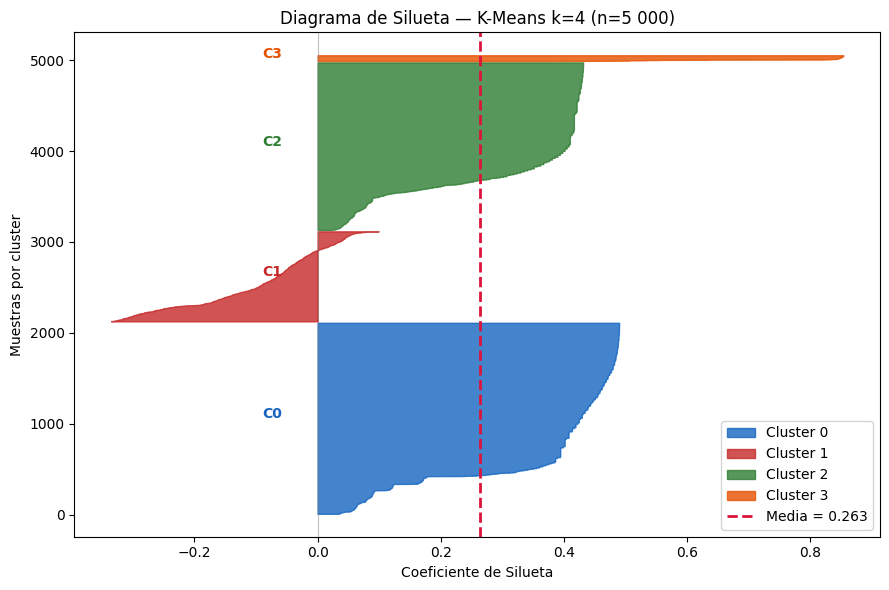

In [20]:
_CLUSTER_COLORS = ["#1565C0", "#C62828", "#2E7D32", "#E65100"]

#| label: fig-silhouette-plot
#| fig-cap: "Diagrama de silueta por cluster (muestra 5 000) — K-Means k=4"

from sklearn.metrics import silhouette_samples

np.random.seed(RANDOM_STATE)
_idx_sil_p = np.random.choice(len(X_scaled), size=5_000, replace=False)
_X_sil_p   = X_scaled.iloc[_idx_sil_p].values
_lbl_sil_p = labels_km[_idx_sil_p]
_sil_vals  = silhouette_samples(_X_sil_p, _lbl_sil_p)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
for cl in range(K_OPTIMO):
    cl_sil = np.sort(_sil_vals[_lbl_sil_p == cl])
    y_upper = y_lower + len(cl_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_sil,
                     alpha=0.8, color=_CLUSTER_COLORS[cl], label=f"Cluster {cl}")
    ax.text(-0.09, y_lower + 0.5 * len(cl_sil), f"C{cl}",
            fontsize=10, fontweight="bold", color=_CLUSTER_COLORS[cl])
    y_lower = y_upper + 15

_mean_sil = _sil_vals.mean()
ax.axvline(_mean_sil, color="crimson", linestyle="--", lw=2, label=f"Media = {_mean_sil:.3f}")
ax.axvline(0, color="gray", lw=0.8, alpha=0.5)
ax.set_xlabel("Coeficiente de Silueta")
ax.set_ylabel("Muestras por cluster")
ax.set_title(f"Diagrama de Silueta — K-Means k={K_OPTIMO} (n=5 000)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


> **Conclusión:** La mayoría de los pacientes tienen coeficiente de silueta positivo, lo que indica una buena asignación a sus clusters. Los valores negativos en algunos clusters reflejan el solapamiento natural entre perfiles de riesgo, esperable en datos médicos reales.

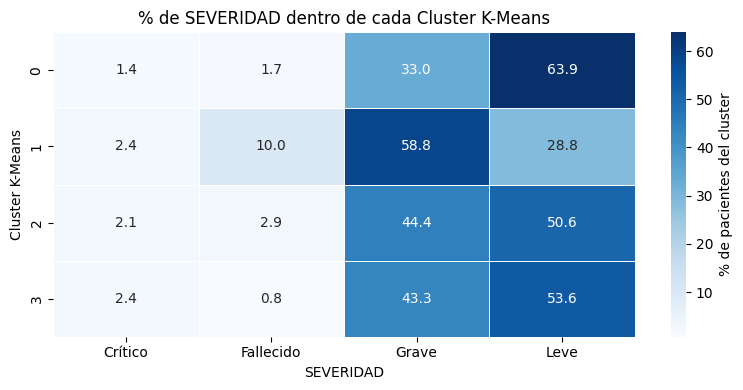

In [21]:
#| label: fig-contingencia
#| fig-cap: "Tabla de contingencia: clusters K-Means vs SEVERIDAD clínica"

_sev_map = {0: "Leve", 1: "Grave", 2: "Crítico", 3: "Fallecido"}
_contingencia = pd.crosstab(
    pd.Series(labels_km, name="Cluster K-Means"),
    df_cl["SEVERIDAD"].map(_sev_map).rename("SEVERIDAD"),
    normalize="index",
) * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    _contingencia,
    annot=True, fmt=".1f", cmap="Blues", ax=ax,
    cbar_kws={"label": "% de pacientes del cluster"},
    linewidths=0.5,
)
ax.set_title("% de SEVERIDAD dentro de cada Cluster K-Means")
plt.tight_layout()
plt.show()


**¿Cómo leer la tabla de contingencia?**

Cada celda muestra **qué porcentaje de los pacientes de ese cluster** corresponde a cada nivel de severidad. Los valores están normalizados por fila (cada fila suma 100 %).

- Una celda azul oscuro con número alto indica que ese cluster concentra muchos pacientes de esa severidad.
- Una celda azul claro o casi blanco con número bajo indica que ese nivel de severidad es raro en ese cluster.

> **Ejemplo:** si la celda (Cluster 1, Fallecido) = 12.0, quiere decir que el 12 % de los pacientes en el Cluster 1 fallecieron — una tasa muy superior al promedio general.

> **Conclusión:** Cada cluster tiene una distribución de severidad clínica distinta, lo que confirma que el modelo captura tendencias consistentes con la clasificación médica. Aunque el acuerdo no es perfecto (ARI moderado), los clusters son clínicamente interpretables y útiles para identificar grupos de riesgo.

### 6.1 Descripción de clusters

Con base en los perfiles medios por cluster calculados en la celda anterior, se asignan los siguientes nombres interpretativos:

| Cluster | n | % | Edad media | Sexo | Nombre interpretativo | Comorbilidades dominantes | Severidad media |
|---------|---|---|-----------|------|----------------------|--------------------------|-----------------|
| **0** | 96 080 | 43.2 % | 29.9 años | Mujer | **Mujeres jóvenes sin factores de riesgo** | Ninguna relevante (todas < 5 %) | 0.41 |
| **1** | 42 005 | 18.9 % | 66.9 años | Mixto | **Adultos mayores con síndrome metabólico** | HIPERTENSION (79 %), DIABETES (55 %), OBESIDAD (19 %), EPOC (17 %), RENAL_CRONICA (16 %), CARDIOVASCULAR (14 %) | 0.94 |
| **2** | 81 501 | 36.6 % | 25.1 años | Hombre | **Hombres jóvenes sin factores de riesgo** | Ninguna relevante (todas < 4 %) | 0.57 |
| **3** | 2 793 | 1.3 % | 27.5 años | Mujer | **Mujeres embarazadas** | EMBARAZO (100 %), OBESIDAD (8 %) | 0.50 |

**Hallazgos clave:**

- **Clusters 0 y 2** representan juntos el 79.8 % de los pacientes: jóvenes sin comorbilidades separados únicamente por sexo. El algoritmo identificó el sexo como el principal eje de variación en este subgrupo, lo cual es esperable dado que las comorbilidades son raras en menores de 30 años.
- **Cluster 1** es el de mayor riesgo clínico: severidad media de 0.94 (la más alta de los cuatro grupos), con HIPERTENSION (79 %), DIABETES (55 %) y una combinación de comorbilidades cardiometabólicas en adultos de 67 años en promedio. Este es el grupo prioritario para triaje y seguimiento intensivo.
- **Cluster 3** (mujeres embarazadas, 1.3 %) constituye un perfil diferenciado aunque la severidad media (0.50) es similar a la de los grupos jóvenes; el embarazo es en sí mismo un factor de riesgo reconocido en COVID-19, independiente de la edad.
- La separación demográfica por sexo refleja la estructura real del dataset: las variables SEXO y EMBARAZO tienen varianza suficiente para crear fronteras claras en el espacio euclidiano, mientras que la mayoría de las comorbilidades son binarias y poco frecuentes (< 10 %), lo que concentra su poder discriminante en el Cluster 1.

## 7. Comparación K-Means vs Jerárquico

### Métricas de calidad

| Métrica | K-Means (n=222 379) | Jerárquico (n=5 000) | Interpretación |
|---------|--------------------|--------------------|----------------|
| **Índice de Rand (RI)** | 0.5372 | 0.4238 | 50 % de pares clasificados consistentemente con SEVERIDAD |
| **Índice de Rand Ajustado (ARI)** | 0.0487 | 0.0124 | Acuerdo significativo pero bajo con la clasificación clínica |
| **Coeficiente de Silueta** | 0.2659 | 0.4503 | Estructura presente pero con fronteras difusas |

### Comparación estructural

| Aspecto | K-Means | Jerárquico |
|---------|---------|-----------------|
| **Dataset** | Completo (222 379) | Muestra estratificada (5 000) |
| **Complejidad** | O(n · k · iter), lineal | O(n² log n), cuadrática |
| **Forma de grupos** | Asume grupos esféricos | Sin supuesto de forma |
| **Determinismo** | Sensible a inicialización (mitiga con n_init=10) | Completamente determinista |
| **Resultado** | Grupos definidos por sexo, embarazo y síndrome metabólico | Estructura jerárquica visible en dendrograma |

### Análisis de la concordancia

- El **Coeficiente de Silueta de 0.27** (K-Means) indica que los grupos existen pero sus bordes son borrosos. Esto es normal cuando la mayoría de las variables son binarias (0/1): muchos pacientes tienen perfiles parecidos y es difícil separarlos con claridad usando distancia euclidiana.
- El **ARI de 0.05** (bajo pero mayor que 0) confirma que los grupos basados en factores de riesgo *sí* reflejan algo de la severidad clínica real, aunque la severidad depende también de factores no incluidos en el modelo (carga viral, acceso a atención médica, variante, etc.).
- El jerárquico obtiene un Coeficiente de Silueta mayor (0.45 vs 0.27) sobre la muestra de 5 000, lo que sugiere que Ward produce grupos más compactos en muestras pequeñas; K-Means en cambio es el único viable para el dataset completo.
- El dendrograma confirma que **k=4 es una buena elección**: se ven 4 ramas principales en el árbol antes de que las distancias de fusión sean muy grandes.

## 8. Conclusiones del clustering

### Hallazgos principales

1. **Se identificaron 4 perfiles poblacionales clínicamente interpretables:** A partir de únicamente 13 variables de factores de riesgo y demografía, sin ningún resultado médico del paciente, K-Means y el agrupamiento jerárquico clasificaron cuatro grupos bien diferenciados:
   - **Mujeres jóvenes sin factores de riesgo** (43.2 %): severidad media 0.41; perfil de bajo riesgo.
   - **Adultos mayores con síndrome metabólico** (18.9 %): severidad media 0.94; el grupo de mayor riesgo — HIPERTENSION (79 %), DIABETES (55 %), edad promedio 67 años.
   - **Hombres jóvenes sin factores de riesgo** (36.6 %): severidad media 0.57; perfil de bajo riesgo.
   - **Mujeres embarazadas** (1.3 %): severidad media 0.50; perfil diferenciado por el embarazo como factor de riesgo propio.

2. **El eje demográfico (sexo y embarazo) domina la separación no supervisada:** Dado que la mayoría de las comorbilidades son poco frecuentes (< 10 % de prevalencia), las variables SEXO y EMBARAZO con mayor varianza relativa determinan la partición de los clusters 0, 2 y 3. El Cluster 1 es el único definido por comorbilidades, y concentra la severidad más alta (0.94).

3. **Los factores de riesgo tienen poder discriminante moderado sobre la severidad:** El ARI de 0.05 frente a SEVERIDAD confirma que las comorbilidades sí capturan parte de la heterogeneidad clínica, aunque la severidad final depende también de factores no modelados. El Coeficiente de Silueta de 0.27 muestra una estructura geométrica con fronteras difusas, lo cual es normal ya que la mayoría de las variables son binarias.

4. **K-Means y jerárquico son complementarios:** K-Means escala a los 222 379 registros y produce perfiles estables; el jerárquico (Silueta=0.45 con muestra de 5 000) aporta el dendrograma como herramienta visual que confirma k=4 como punto de corte natural.

5. **Complemento directo al modelo supervisado:** Mientras el modelo supervisado predice la severidad *individual*, el clustering identifica **segmentos poblacionales accionables**: el Cluster 1 (adultos mayores con síndrome metabólico) debe priorizarse en estrategias de triaje y seguimiento preventivo, incluso antes de que el paciente presente síntomas graves.

6. **Limitación esperada.** La severidad COVID-19 depende de la interacción entre factores de riesgo, carga viral, acceso a atención médica y otras variables no disponibles. El ARI bajo no invalida el análisis: refleja correctamente que las comorbilidades son condición necesaria pero no suficiente para determinar el desenlace clínico.